# **Pertemuan 2: Ekstraksi Fitur: Dari Tepi Hingga Deteksi Wajah**

**Tujuan Sesi:**  
Peserta belajar cara mengekstrak fitur penting dari citra seperti tepi dan bentuk, dan menggunakannya untuk mendeteksi objek kompleks seperti wajah.

## **Pengantar**

### **Konsep Konvolusi dan Deteksi Tepi**

Dalam pengolahan citra digital, **konvolusi** merupakan operasi penting yang memungkinkan kita untuk memanipulasi fitur visual dari gambar.  
Beberapa penerapannya antara lain:  
- **Blurring (reduksi noise)**: menggunakan kernel untuk meratakan nilai piksel di sekitarnya, sehingga detail halus dan noise berkurang.  
- **Sharpening**: meningkatkan kontras antar piksel agar tepi objek terlihat lebih tajam.  

Selanjutnya, kita akan mengenal **algoritma Canny Edge Detector**, salah satu metode paling populer untuk **menemukan garis batas objek** pada gambar.  
Metode ini bekerja dengan mendeteksi perubahan intensitas yang signifikan, lalu menandai area tersebut sebagai **tepi**.

## **Filter Spasial dan Deteksi Tepi**

**Konvolusi** adalah operasi matematika yang menggabungkan dua fungsi untuk menghasilkan fungsi ketiga. Dalam pengolahan citra, konvolusi digunakan untuk menerapkan **kernel** (matriks kecil) pada setiap piksel gambar.

**Jenis-jenis filter spatial:**
- **Gaussian Blur**: Mengurangi noise dengan meratakan nilai piksel
- **Sharpening**: Meningkatkan kontras tepi untuk membuat gambar lebih tajam
- **Edge Detection**: Mendeteksi perubahan intensitas yang signifikan (tepi objek)

**Canny Edge Detector** adalah algoritma deteksi tepi yang paling populer karena:
1. Mampu mendeteksi tepi dengan akurat
2. Menghasilkan tepi yang tipis (1 piksel)
3. Mengurangi noise dengan baik

> **Pertanyaan:** Apakah kamu sudah melakukan instalasi library `dlib`?

In [3]:
# Import library yang dibutuhkan
import numpy as np  # Untuk operasi numerik dan manipulasi array
import matplotlib.pyplot as plt  # Untuk visualisasi gambar
import cv2  # OpenCV: library utama untuk pengolahan citra dan aplikasi terkait
import os  # Untuk operasi file dan path
import dlib  # Deteksi wajah & landmark

# Cek versi library yang diinstal
print(f"Versi numpy: {np.__version__}")
print(f"Versi matplotlib: {plt.matplotlib.__version__}")
print(f"Versi OpenCV: {cv2.__version__}")
print("Versi dlib:", dlib.__version__)

"""
📌 Catatan Penting:
Cara Instal Library
dlib → digunakan untuk deteksi wajah.
   - Instalasi di Windows bisa rumit.
   - Panduan lengkap: https://www.geeksforgeeks.org/python/how-to-install-dlib-library-for-python-in-windows-10/

💡 Disarankan menggunakan versi Python 3.10 atau 3.11 agar kompatibel.
"""

Versi numpy: 2.4.6
Versi matplotlib: 3.10.9
Versi OpenCV: 4.13.0
Versi dlib: 20.0.1


'\n📌 Catatan Penting:\nCara Instal Library\ndlib → digunakan untuk deteksi wajah.\n   - Instalasi di Windows bisa rumit.\n   - Panduan lengkap: https://www.geeksforgeeks.org/python/how-to-install-dlib-library-for-python-in-windows-10/\n\n💡 Disarankan menggunakan versi Python 3.10 atau 3.11 agar kompatibel.\n'

In [4]:
# Panggil file
geo_img = os.path.join(os.getcwd(), 'data', 'shape.png')
img = cv2.imread(geo_img)

# Konversi ke RGB untuk ditampilkan dengan benar di matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

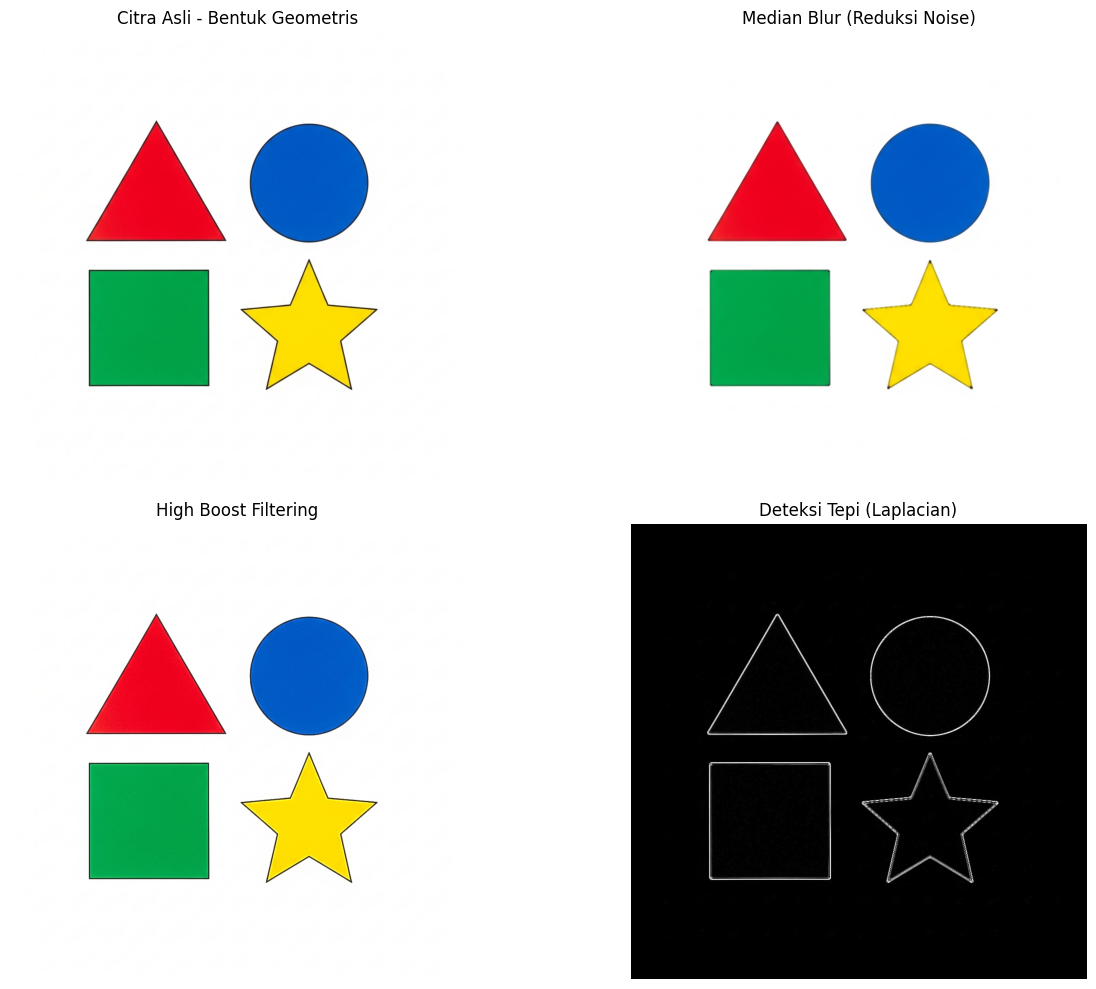

In [5]:
# =====================================================
# Median Blur (Reduksi Noise)
# =====================================================
blur = cv2.medianBlur(img, 7)
blur_rgb = cv2.cvtColor(blur, cv2.COLOR_BGR2RGB)

# =====================================================
# High Boost Filtering (Penajaman)
# =====================================================
gaussian = cv2.GaussianBlur(img, (9, 9), 0)

mask = cv2.subtract(img, gaussian)

sharp = cv2.addWeighted(
    img,
    1.0,
    mask,
    1.8,
    0
)

sharp_rgb = cv2.cvtColor(sharp, cv2.COLOR_BGR2RGB)

# =====================================================
# Laplacian Edge Detection
# =====================================================
gray = cv2.cvtColor(blur, cv2.COLOR_BGR2GRAY)

edges = cv2.Laplacian(
    gray,
    cv2.CV_64F,
    ksize=3
)

edges = cv2.convertScaleAbs(edges)

# =====================================================
# Visualisasi
# =====================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title("Citra Asli - Bentuk Geometris", fontsize=12)
axes[0, 0].axis("off")

axes[0, 1].imshow(blur_rgb)
axes[0, 1].set_title("Median Blur (Reduksi Noise)", fontsize=12)
axes[0, 1].axis("off")

axes[1, 0].imshow(sharp_rgb)
axes[1, 0].set_title("High Boost Filtering", fontsize=12)
axes[1, 0].axis("off")

axes[1, 1].imshow(edges, cmap='gray')
axes[1, 1].set_title("Deteksi Tepi (Laplacian)", fontsize=12)
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

### **Penjelasan Filter Spatial**

**Gaussian Blur (`cv2.GaussianBlur`)**:
- Parameter `(15, 15)` adalah ukuran kernel blur
- Semakin besar kernel, semakin blur hasilnya
- Berguna untuk mengurangi noise sebelum deteksi tepi

**Sharpening Filter**:
- Menggunakan kernel `[[0,-1,0], [-1,5,-1], [0,-1,0]]`
- Nilai tengah (5) memperkuat piksel pusat
- Nilai negatif (-1) mengurangi piksel sekitar
- Hasilnya: kontras tepi meningkat

**Canny Edge Detection**:
- Parameter `(100, 200)` adalah threshold rendah dan tinggi
- Piksel dengan gradien > 200 pasti tepi
- Piksel dengan gradien < 100 pasti bukan tepi
- Piksel di antara 100-200 diperiksa koneksinya

### **Menerapkan Canny dengan Threshold Berbeda**

Threshold Canny menentukan sensitivitas deteksi tepi:
- **Threshold rendah (30, 90)**: Sensitif, mendeteksi banyak tepi termasuk noise
- **Threshold sedang (50, 150)**: Seimbang antara detail dan noise
- **Threshold tinggi (100, 200)**: Ketat, hanya tepi kuat yang terdeteksi

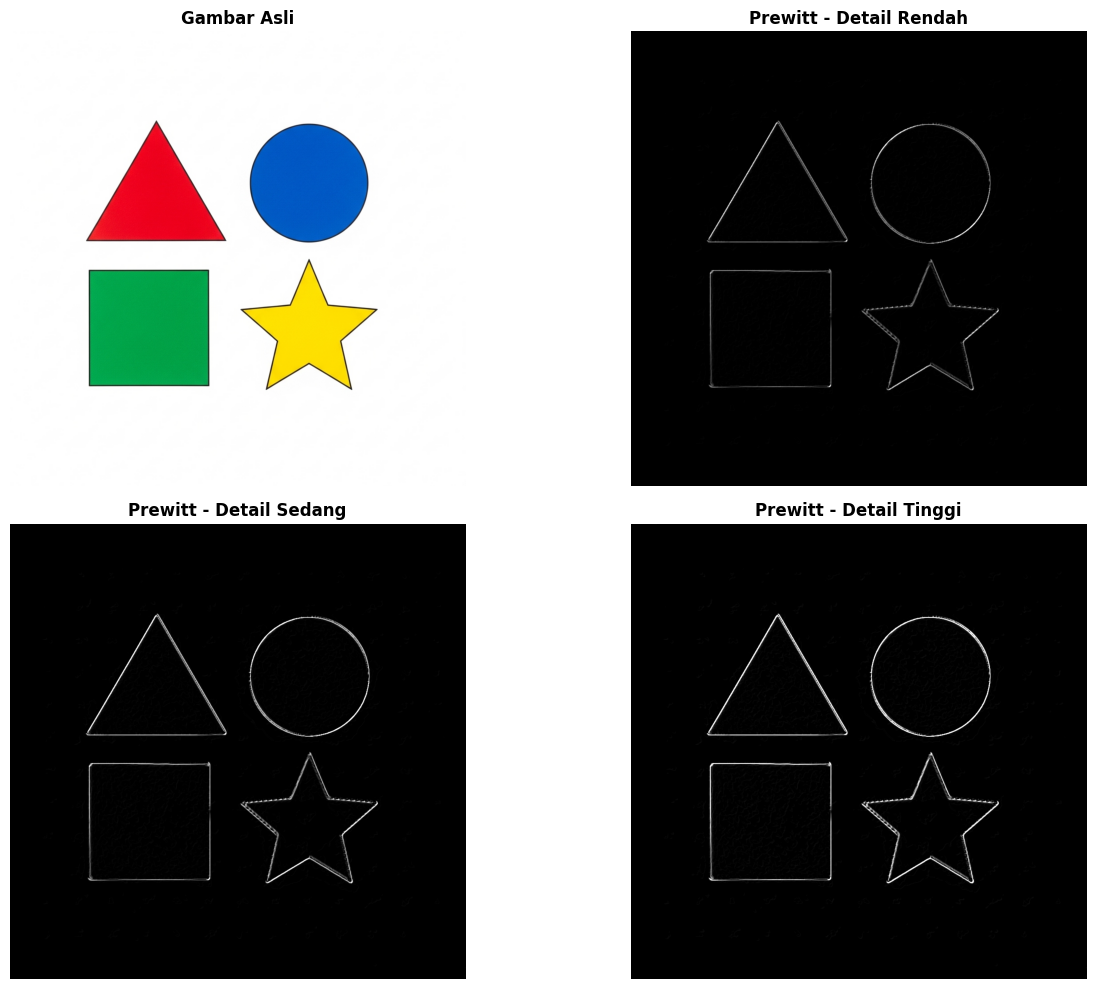

In [6]:
# =====================================================
# Preprocessing
# Median Blur
# =====================================================
img_blur = cv2.medianBlur(edges, 5)

# =====================================================
# Prewitt Edge Detection
# =====================================================

# Kernel Prewitt Horizontal
kernelx = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
])

# Kernel Prewitt Vertikal
kernely = np.array([
    [1, 1, 1],
    [0, 0, 0],
    [-1, -1, -1]
])

# Prewitt Level 1
prewitt_x1 = cv2.filter2D(img_blur, -1, kernelx)
prewitt_y1 = cv2.filter2D(img_blur, -1, kernely)
edges_low = cv2.addWeighted(prewitt_x1, 0.5, prewitt_y1, 0.5, 0)

# Prewitt Level 2
edges_mid = cv2.convertScaleAbs(edges_low * 1.5)

# Prewitt Level 3
edges_high = cv2.convertScaleAbs(edges_low * 2.0)

# =====================================================
# Visualisasi Hasil
# =====================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title(
    "Gambar Asli",
    fontsize=12,
    fontweight='bold'
)
axes[0, 0].axis("off")

axes[0, 1].imshow(edges_low, cmap='gray')
axes[0, 1].set_title(
    "Prewitt - Detail Rendah",
    fontsize=12,
    fontweight='bold'
)
axes[0, 1].axis("off")

axes[1, 0].imshow(edges_mid, cmap='gray')
axes[1, 0].set_title(
    "Prewitt - Detail Sedang",
    fontsize=12,
    fontweight='bold'
)
axes[1, 0].axis("off")

axes[1, 1].imshow(edges_high, cmap='gray')
axes[1, 1].set_title(
    "Prewitt - Detail Tinggi",
    fontsize=12,
    fontweight='bold'
)
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

### **Tips memilih threshold:**
- Gambar ber-noise tinggi → gunakan threshold tinggi
- Butuh detail halus → gunakan threshold rendah
- Untuk deteksi kontur → pilih threshold sedang

### **Deteksi Kontur**

**Kontur** adalah kurva yang menghubungkan titik-titik kontinu dengan intensitas warna yang sama. Dalam pengolahan citra, kontur sering digunakan untuk mendeteksi bentuk, ukuran, dan lokasi objek.

Langkah-langkah deteksi kontur:
- **Preprocessing**: Menggunakan Gaussian blur untuk mengurangi noise dan Canny edge detection untuk menemukan tepi.
- **Kontur eksternal**: Menggunakan `cv2.findContours` untuk mendeteksi hanya kontur luar.
- **Filter area**: Menyaring kontur berdasarkan ukuran untuk menghilangkan noise kecil atau objek yang tidak relevan.

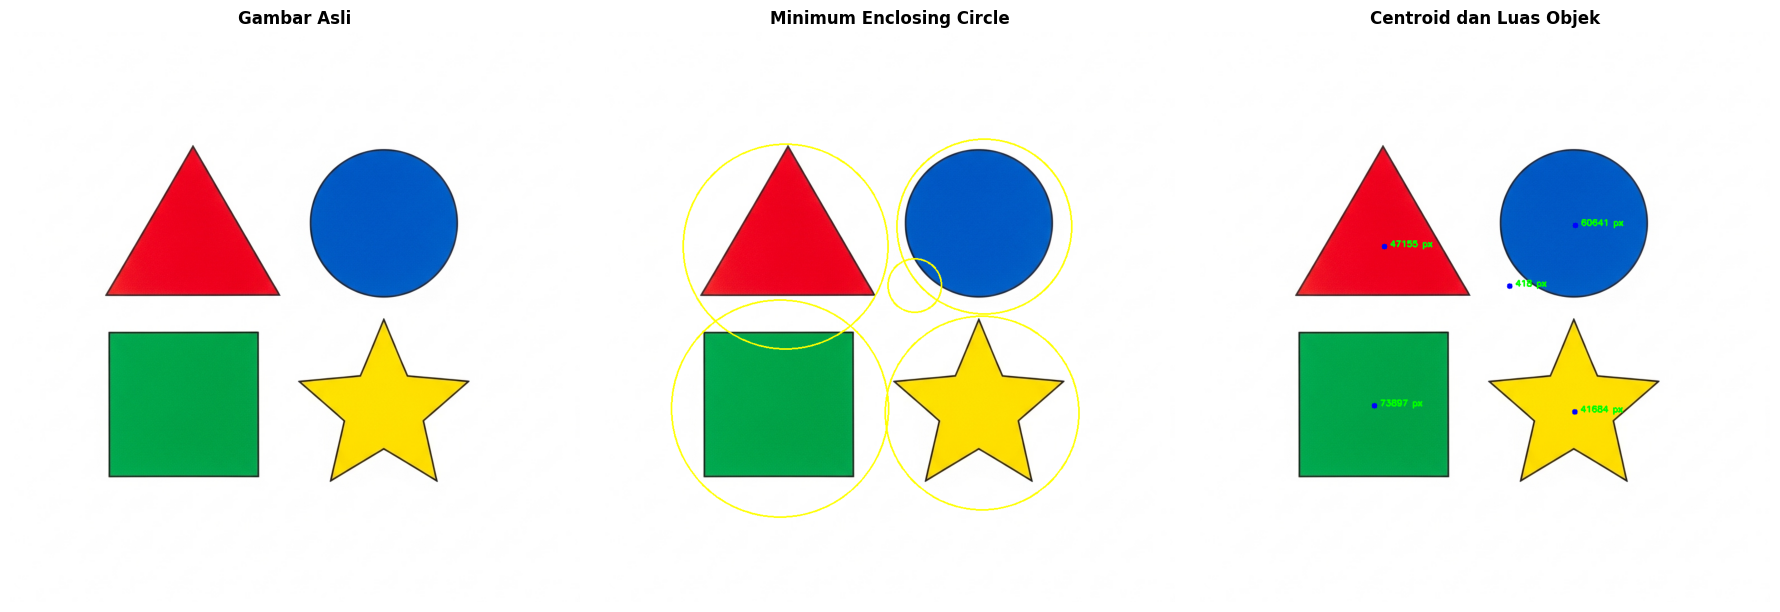

In [7]:
# =====================================================
# DETEKSI KONTUR
# =====================================================
contours, hierarchy = cv2.findContours(
    edges_mid,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# =====================================================
# VISUALISASI 1
# Lingkaran Pembungkus Objek
# =====================================================
img_circle = img.copy()

for c in contours:

    area = cv2.contourArea(c)

    # Abaikan noise kecil
    if area < 300:
        continue

    (x, y), radius = cv2.minEnclosingCircle(c)

    center = (int(x), int(y))
    radius = int(radius)

    cv2.circle(
        img_circle,
        center,
        radius,
        (0, 255, 255),
        2
    )

# =====================================================
# VISUALISASI 2
# Titik Tengah + Luas Objek
# =====================================================
img_info = img.copy()

for c in contours:

    area = cv2.contourArea(c)

    if area < 300:
        continue

    M = cv2.moments(c)

    if M["m00"] != 0:

        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])

        # Titik tengah
        cv2.circle(
            img_info,
            (cx, cy),
            5,
            (255, 0, 0),
            -1
        )

        # Luas objek
        cv2.putText(
            img_info,
            f"{int(area)} px",
            (cx + 10, cy),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            2
        )

# =====================================================
# VISUALISASI
# =====================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title(
    "Gambar Asli",
    fontsize=12,
    fontweight='bold'
)
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(img_circle, cv2.COLOR_BGR2RGB))
axes[1].set_title(
    "Minimum Enclosing Circle",
    fontsize=12,
    fontweight='bold'
)
axes[1].axis("off")

axes[2].imshow(cv2.cvtColor(img_info, cv2.COLOR_BGR2RGB))
axes[2].set_title(
    "Centroid dan Luas Objek",
    fontsize=12,
    fontweight='bold'
)
axes[2].axis("off")

plt.tight_layout()
plt.show()

### **Penjelasan**

**Parameter `cv2.findContours()`:**
- **Input**: Gambar biner (hasil Canny)
- `cv2.RETR_EXTERNAL`: Hanya kontur luar (tidak ada kontur di dalam kontur)
- `cv2.CHAIN_APPROX_SIMPLE`: Menyimpan hanya titik ujung garis

**Proses filtering:**
1. Hitung area setiap kontur dengan `cv2.contourArea()`
2. Filter berdasarkan area minimum (hilangkan noise kecil)
3. Filter berdasarkan area maksimum (hilangkan frame gambar)
4. Urutkan dari area terbesar ke terkecil

**Visualisasi hasil:**
- Kontur digambar dengan warna hijau
- Setiap objek memiliki bounding box berwarna berbeda
- Label nomor menunjukkan urutan berdasarkan ukuran

In [8]:
# Muat gambar
desk_img_path = os.path.join(os.getcwd(), 'data', 'desk.png')
img2 = cv2.imread(desk_img_path)

# Ke grayscale
desk_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

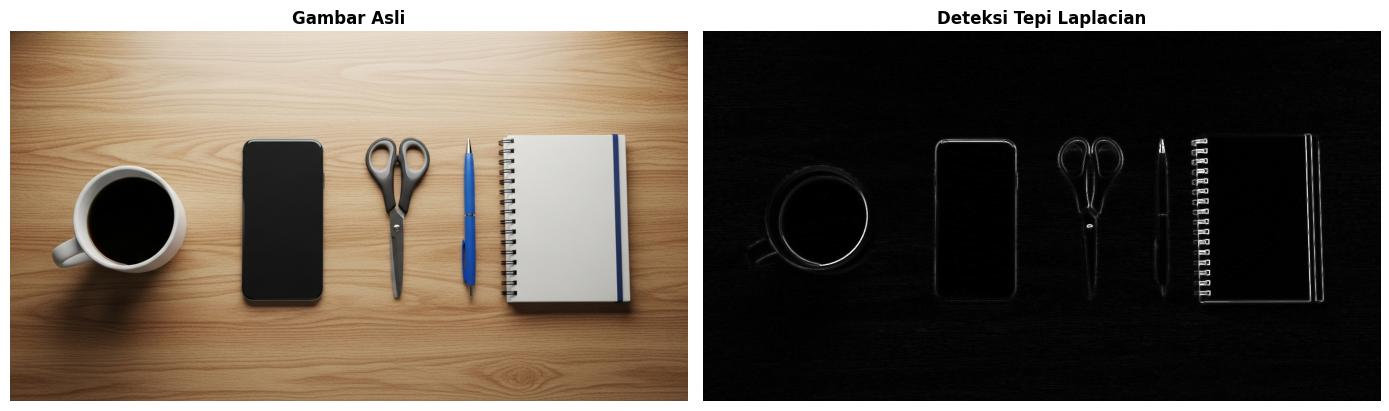

In [9]:
# =====================================================
# Preprocessing
# Bilateral Filter
# =====================================================
desk_blur = cv2.bilateralFilter(desk_gray, 9, 75, 75)

# =====================================================
# Deteksi Tepi Laplacian
# =====================================================
edges = cv2.Laplacian(
    desk_blur,
    cv2.CV_64F,
    ksize=3
)

edges = cv2.convertScaleAbs(edges)

# =====================================================
# Visualisasi
# =====================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

axes[0].imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
axes[0].set_title(
    "Gambar Asli",
    fontsize=12,
    fontweight='bold'
)
axes[0].axis("off")

axes[1].imshow(edges, cmap='gray')
axes[1].set_title(
    "Deteksi Tepi Laplacian",
    fontsize=12,
    fontweight='bold'
)
axes[1].axis("off")

plt.tight_layout()
plt.show()

HANDS-ON 2: ANALISIS OBJEK MENGGUNAKAN CONVEX HULL
Jumlah kontur awal : 1856
Jumlah kontur valid : 17


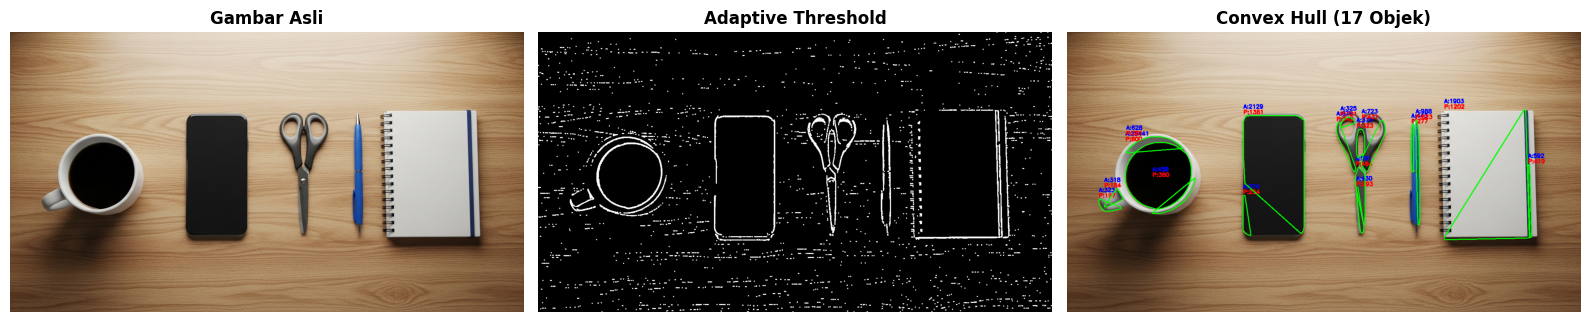

✓ Analisis objek selesai



In [10]:
print("="*60)
print("HANDS-ON 2: ANALISIS OBJEK MENGGUNAKAN CONVEX HULL")
print("="*60)

# ==========================================
# Threshold adaptif
# ==========================================
thresh = cv2.adaptiveThreshold(
    desk_gray,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    11,
    2
)

# ==========================================
# Mengurangi noise
# ==========================================
kernel = np.ones((3,3), np.uint8)

clean = cv2.morphologyEx(
    thresh,
    cv2.MORPH_OPEN,
    kernel,
    iterations=1
)

# ==========================================
# Deteksi kontur
# ==========================================
contours, hierarchy = cv2.findContours(
    clean,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

print(f"Jumlah kontur awal : {len(contours)}")

# ==========================================
# Filter objek
# ==========================================
selected_contours = []

for cnt in contours:

    area = cv2.contourArea(cnt)

    if area > 300:
        selected_contours.append(cnt)

print(f"Jumlah kontur valid : {len(selected_contours)}")

# ==========================================
# Visualisasi Convex Hull
# ==========================================
img_hull = img2.copy()

for i, cnt in enumerate(selected_contours):

    hull = cv2.convexHull(cnt)

    cv2.drawContours(
        img_hull,
        [hull],
        -1,
        (0, 255, 0),
        2
    )

    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)

    x, y, w, h = cv2.boundingRect(cnt)

    cv2.putText(
        img_hull,
        f"A:{int(area)}",
        (x, y-20),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 0, 0),
        2
    )

    cv2.putText(
        img_hull,
        f"P:{int(perimeter)}",
        (x, y-5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 0, 255),
        2
    )

# ==========================================
# Visualisasi Hasil
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
axes[0].set_title("Gambar Asli", fontsize=12, fontweight='bold')
axes[0].axis("off")

axes[1].imshow(clean, cmap='gray')
axes[1].set_title("Adaptive Threshold", fontsize=12, fontweight='bold')
axes[1].axis("off")

axes[2].imshow(cv2.cvtColor(img_hull, cv2.COLOR_BGR2RGB))
axes[2].set_title(
    f"Convex Hull ({len(selected_contours)} Objek)",
    fontsize=12,
    fontweight='bold'
)
axes[2].axis("off")

plt.tight_layout()
plt.show()

print("✓ Analisis objek selesai")
print()

### **Penjelasan Sistem Anotasi**

**Tiga jenis anotasi:**

1. **Kontur Warna-warni:**
   - Setiap objek diberi warna berbeda
   - Warna dihitung berdasarkan indeks objek
   - Memudahkan membedakan objek yang berdekatan

2. **Bounding Box + Label:**
   - Kotak pembatas menunjukkan area objek
   - Warna berdasarkan ukuran: biru (besar), hijau (sedang), orange (kecil)
   - Label nomor untuk identifikasi

3. **Kombinasi Lengkap:**
   - Kontur + bounding box + informasi area
   - Memberikan informasi paling lengkap
   - Berguna untuk analisis detail

**Fungsi OpenCV yang digunakan:**
- `cv2.rectangle()`: Menggambar kotak
- `cv2.putText()`: Menambah teks label
- `cv2.contourArea()`: Menghitung luas area
- `cv2.boundingRect()`: Koordinat kotak pembatas

HANDS-ON 2: DETEKSI KONTUR DAN BOUNDING BOX
Jumlah kontur awal : 6
Jumlah kontur valid : 6


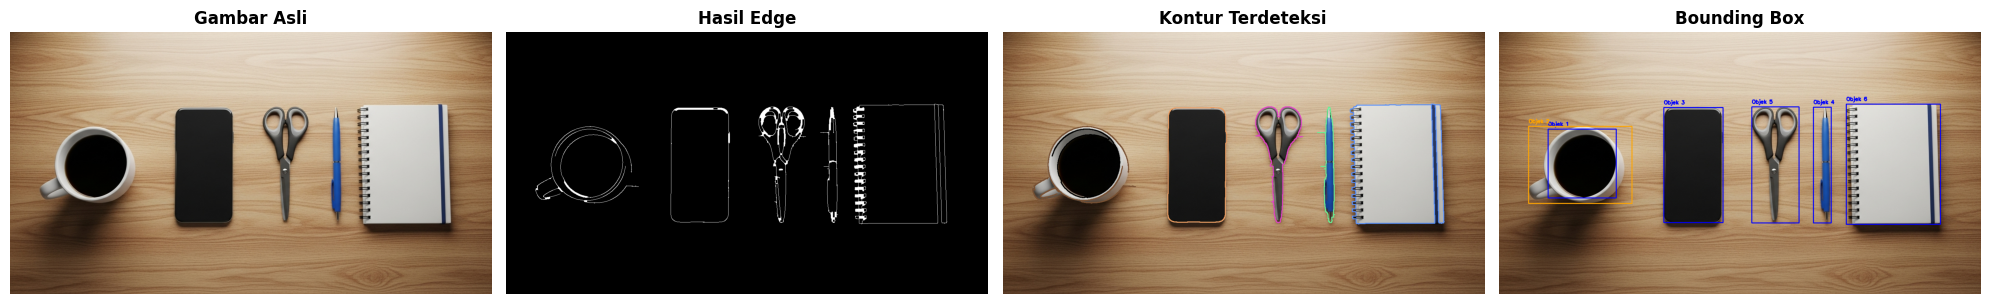

✓ Deteksi kontur berhasil
✓ Bounding box berhasil dibuat


In [11]:
print("="*60)
print("HANDS-ON 2: DETEKSI KONTUR DAN BOUNDING BOX")
print("="*60)

# =====================================================
# PREPROCESSING
# =====================================================

# Blur untuk mengurangi noise
desk_blur = cv2.GaussianBlur(desk_gray, (5, 5), 0)

# Deteksi tepi
edges = cv2.Canny(desk_blur, 50, 150)

# Operasi morfologi untuk menutup celah pada tepi
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
edges_closed = cv2.morphologyEx(
    edges,
    cv2.MORPH_CLOSE,
    kernel,
    iterations=2
)

# =====================================================
# DETEKSI KONTUR
# =====================================================

contours, hierarchy = cv2.findContours(
    edges_closed,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

print("Jumlah kontur awal :", len(contours))

# =====================================================
# FILTER BERDASARKAN LUAS AREA
# =====================================================

filtered_contours = []

min_area = 200
max_area = desk_gray.shape[0] * desk_gray.shape[1] * 0.8

for c in contours:

    area = cv2.contourArea(c)

    if min_area < area < max_area:
        filtered_contours.append(c)

print("Jumlah kontur valid :", len(filtered_contours))

# =====================================================
# GAMBAR KONTUR
# =====================================================

img_contours = img2.copy()

for idx, c in enumerate(filtered_contours):

    color = (
        int((idx * 50) % 255),
        int((idx * 80) % 255),
        int((idx * 120) % 255)
    )

    cv2.drawContours(
        img_contours,
        [c],
        -1,
        color,
        2
    )

# =====================================================
# BOUNDING BOX + LABEL
# =====================================================

img_boxes = img2.copy()

for idx, c in enumerate(filtered_contours):

    x, y, w, h = cv2.boundingRect(c)

    area = cv2.contourArea(c)

    # Warna berdasarkan ukuran objek
    if area > 5000:
        color = (255, 0, 0)
    elif area > 2000:
        color = (0, 255, 0)
    else:
        color = (0, 165, 255)

    cv2.rectangle(
        img_boxes,
        (x, y),
        (x + w, y + h),
        color,
        2
    )

    cv2.putText(
        img_boxes,
        f"Objek {idx+1}",
        (x, y - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        color,
        2
    )

# =====================================================
# VISUALISASI
# =====================================================

fig, axes = plt.subplots(1, 4, figsize=(20, 6))

axes[0].imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
axes[0].set_title("Gambar Asli", fontsize=12, fontweight='bold')
axes[0].axis("off")

axes[1].imshow(edges_closed, cmap='gray')
axes[1].set_title("Hasil Edge", fontsize=12, fontweight='bold')
axes[1].axis("off")

axes[2].imshow(cv2.cvtColor(img_contours, cv2.COLOR_BGR2RGB))
axes[2].set_title("Kontur Terdeteksi", fontsize=12, fontweight='bold')
axes[2].axis("off")

axes[3].imshow(cv2.cvtColor(img_boxes, cv2.COLOR_BGR2RGB))
axes[3].set_title("Bounding Box", fontsize=12, fontweight='bold')
axes[3].axis("off")

plt.tight_layout()
plt.show()

print("✓ Deteksi kontur berhasil")
print("✓ Bounding box berhasil dibuat")

> **Pertanyaan:** Bagaimana mengoptimalkan kontur agar terdeteksi hanya 4 objek?

## **Deteksi Wajah dengan Haar Cascades**

**Haar Cascade** adalah metode machine learning untuk deteksi objek yang dikembangkan oleh Paul Viola dan Michael Jones. Karakteristik utama:

- Menggunakan **fitur Haar-like** (pola terang-gelap sederhana)
- **Cascade classifier**: Serangkaian classifier lemah yang digabung
- **Cepat**: Dapat berjalan real-time pada webcam
- **Pre-trained**: OpenCV menyediakan model siap pakai

**Keunggulan:**
- Tidak perlu training data sendiri
- Akurasi cukup baik untuk wajah frontal
- Komputasi ringan

Jumlah wajah terdeteksi: 1


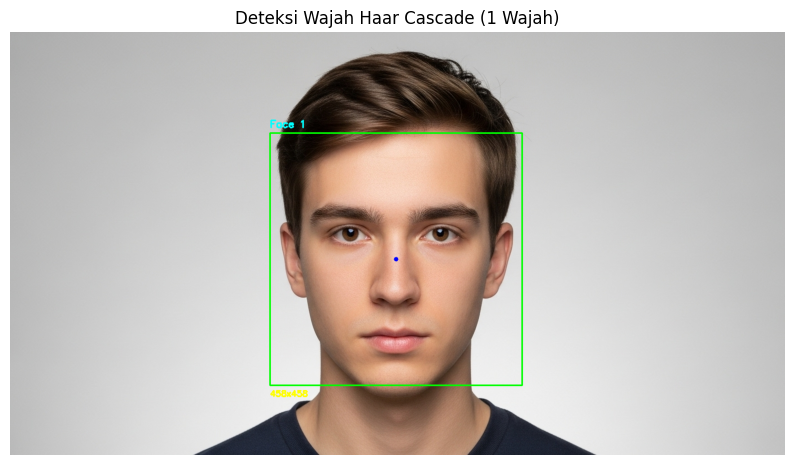

In [12]:
# =====================================================
# DETEKSI WAJAH MENGGUNAKAN HAAR CASCADE
# =====================================================

haar_cascade_path = os.path.join(
    cv2.data.haarcascades,
    'haarcascade_frontalface_default.xml'
)

face_cascade = cv2.CascadeClassifier(haar_cascade_path)

# Membaca gambar
face_path = os.path.join(
    os.getcwd(),
    'data',
    'face.png'
)

img3 = cv2.imread(face_path)

# Validasi gambar
if img3 is None:
    raise FileNotFoundError(
        f"Gambar tidak ditemukan:\n{face_path}"
    )

# Konversi ke grayscale
gray_face = cv2.cvtColor(
    img3,
    cv2.COLOR_BGR2GRAY
)

# Deteksi wajah
faces = face_cascade.detectMultiScale(
    gray_face,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30)
)

print(f"Jumlah wajah terdeteksi: {len(faces)}")

# =====================================================
# ANOTASI HASIL DETEKSI
# =====================================================

result = img3.copy()

for i, (x, y, w, h) in enumerate(faces):

    # Bounding box
    cv2.rectangle(
        result,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        2
    )

    # Titik tengah wajah
    center_x = x + w // 2
    center_y = y + h // 2

    cv2.circle(
        result,
        (center_x, center_y),
        4,
        (255, 0, 0),
        -1
    )

    # Label wajah
    cv2.putText(
        result,
        f"Face {i+1}",
        (x, y - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255, 255, 0),
        2
    )

    # Ukuran wajah
    cv2.putText(
        result,
        f"{w}x{h}",
        (x, y + h + 20),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 255, 255),
        2
    )

# =====================================================
# VISUALISASI
# =====================================================

result_rgb = cv2.cvtColor(
    result,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(10, 6))

plt.imshow(result_rgb)

plt.title(
    f"Deteksi Wajah Haar Cascade ({len(faces)} Wajah)"
)

plt.axis("off")

plt.show()

### **XML Pra Terlatih OpenCV**

OpenCV menyediakan berbagai model Haar Cascade:
- `haarcascade_frontalface_default.xml`: Wajah tampak depan
- `haarcascade_eye.xml`: Mata
- `haarcascade_smile.xml`: Senyuman
- `haarcascade_profileface.xml`: Wajah profil

File XML berisi ribuan fitur yang sudah dilatih pada jutaan gambar positif dan negatif.

In [13]:
# =====================================================
# DETEKSI WAJAH HAAR CASCADE DAN DLIB
# =====================================================

# Haar Cascade
faces_haar = face_cascade.detectMultiScale(
    gray_faces,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30)
)

for i, (x, y, w, h) in enumerate(faces_haar):

    # Bounding box
    cv2.rectangle(
        img_haar,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        2
    )

    # Titik tengah wajah
    center_x = x + w // 2
    center_y = y + h // 2

    cv2.circle(
        img_haar,
        (center_x, center_y),
        4,
        (255, 0, 0),
        -1
    )

    cv2.putText(
        img_haar,
        f"F{i+1}",
        (x, y - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 0),
        2
    )

# =====================================================
# DLIB FACE DETECTOR
# =====================================================

detector = dlib.get_frontal_face_detector()

faces_dlib = detector(gray_faces)

for i, face in enumerate(faces_dlib):

    x1 = face.left()
    y1 = face.top()
    x2 = face.right()
    y2 = face.bottom()

    cv2.rectangle(
        img_dlib,
        (x1, y1),
        (x2, y2),
        (255, 0, 0),
        2
    )

    center_x = (x1 + x2) // 2
    center_y = (y1 + y2) // 2

    cv2.circle(
        img_dlib,
        (center_x, center_y),
        4,
        (0, 255, 255),
        -1
    )

    cv2.putText(
        img_dlib,
        f"F{i+1}",
        (x1, y1 - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255, 0, 0),
        2
    )

# =====================================================
# INFORMASI
# =====================================================

print(f"Haar Cascade mendeteksi {len(faces_haar)} wajah")
print(f"Dlib mendeteksi {len(faces_dlib)} wajah")

# =====================================================
# KONVERSI RGB
# =====================================================

img_original_rgb = cv2.cvtColor(
    img_original,
    cv2.COLOR_BGR2RGB
)

img_haar_rgb = cv2.cvtColor(
    img_haar,
    cv2.COLOR_BGR2RGB
)

img_dlib_rgb = cv2.cvtColor(
    img_dlib,
    cv2.COLOR_BGR2RGB
)

# =====================================================
# VISUALISASI
# =====================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_original_rgb)
axes[0].set_title("Gambar Asli")
axes[0].axis("off")

axes[1].imshow(img_haar_rgb)
axes[1].set_title(f"Haar Cascade ({len(faces_haar)} wajah)")
axes[1].axis("off")

axes[2].imshow(img_dlib_rgb)
axes[2].set_title(f"Dlib ({len(faces_dlib)} wajah)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

NameError: name 'gray_faces' is not defined

In [ ]:
# ========================================
# METODE 1: HAAR CASCADE
# ========================================

faces_haar = face_cascade.detectMultiScale(
    gray_faces,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30)
)

# Visualisasi hasil deteksi
for (x, y, w, h) in faces_haar:

    # Bounding box hijau
    cv2.rectangle(
        img_haar,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        2
    )

    # Titik tengah wajah
    center_x = x + w // 2
    center_y = y + h // 2

    cv2.circle(
        img_haar,
        (center_x, center_y),
        5,
        (0, 0, 255),
        -1
    )

    # Hitung luas area wajah
    area = w * h

    cv2.putText(
        img_haar,
        f"Area: {area}",
        (x, y - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 0),
        2
    )

print(f"Haar Cascade mendeteksi: {len(faces_haar)} wajah")

if len(faces_haar) > 0:

    print("\nInformasi wajah yang terdeteksi:")

    for i, (x, y, w, h) in enumerate(faces_haar):

        center_x = x + w // 2
        center_y = y + h // 2

        area = w * h

        print(
            f"Wajah {i+1}: "
            f"pusat=({center_x},{center_y}), "
            f"ukuran={w}x{h}, "
            f"luas={area} piksel"
        )

Haar Cascade mendeteksi: 4 wajah

Informasi wajah yang terdeteksi:
Wajah 1: pusat=(520,266), ukuran=252x252, luas=63504 piksel
Wajah 2: pusat=(914,277), ukuran=278x278, luas=77284 piksel
Wajah 3: pusat=(174,343), ukuran=253x253, luas=64009 piksel
Wajah 4: pusat=(1234,358), ukuran=278x278, luas=77284 piksel


### **dlib: Deteksi Wajah Berbasis HOG dan CNN**

**dlib** adalah pustaka machine learning yang menyediakan berbagai algoritma untuk pengolahan citra dan visi komputer. Dalam konteks deteksi wajah, dlib menawarkan dua metode utama:

1. **Histogram of Oriented Gradients (HOG)**:
    - Menggunakan fitur gradien arah untuk mendeteksi wajah.
    - Cepat dan ringan, cocok untuk aplikasi real-time.
    - Akurasi baik untuk wajah frontal, tetapi kurang optimal untuk wajah dengan sudut miring.

2. **Convolutional Neural Network (CNN)**:
    - Menggunakan model deep learning untuk deteksi wajah.
    - Lebih akurat dibandingkan HOG, terutama untuk wajah dengan berbagai orientasi.
    - Membutuhkan lebih banyak sumber daya komputasi.

**Keunggulan dlib**:
- Tidak memerlukan file XML seperti Haar Cascade.
- Deteksi lebih akurat dan fleksibel dibandingkan metode tradisional.
- Mendukung deteksi landmark wajah untuk analisis lebih lanjut (misalnya, pelacakan ekspresi).

In [ ]:
# ========================================
# METODE 2: DLIB
# ========================================

# Inisialisasi detector Dlib
detector = dlib.get_frontal_face_detector()

# Deteksi wajah
faces_dlib = detector(gray_faces)

# Visualisasi hasil deteksi
for face in faces_dlib:

    x = face.left()
    y = face.top()
    w = face.width()
    h = face.height()

    # Bounding box
    cv2.rectangle(
        img_dlib,
        (x, y),
        (x + w, y + h),
        (255, 165, 0),   # Orange
        2
    )

    # Titik tengah wajah
    center_x = x + w // 2
    center_y = y + h // 2

    cv2.circle(
        img_dlib,
        (center_x, center_y),
        5,
        (255, 0, 255),   # Ungu
        -1
    )

    # Luas area wajah
    area = w * h

    cv2.putText(
        img_dlib,
        f"Area: {area}",
        (x, y - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255, 165, 0),
        2
    )

print(f"Dlib mendeteksi: {len(faces_dlib)} wajah")

if len(faces_dlib) > 0:

    print("\nInformasi wajah yang terdeteksi:")

    for i, face in enumerate(faces_dlib):

        x = face.left()
        y = face.top()
        w = face.width()
        h = face.height()

        center_x = x + w // 2
        center_y = y + h // 2

        area = w * h

        print(
            f"Wajah {i+1}: "
            f"pusat=({center_x},{center_y}), "
            f"ukuran={w}x{h}, "
            f"luas={area} piksel"
        )

Dlib mendeteksi: 4 wajah

Informasi wajah yang terdeteksi:
Wajah 1: pusat=(532,293), ukuran=216x216, luas=46656 piksel
Wajah 2: pusat=(914,317), ukuran=216x216, luas=46656 piksel
Wajah 3: pusat=(179,380), ukuran=259x259, luas=67081 piksel
Wajah 4: pusat=(1240,380), ukuran=259x259, luas=67081 piksel


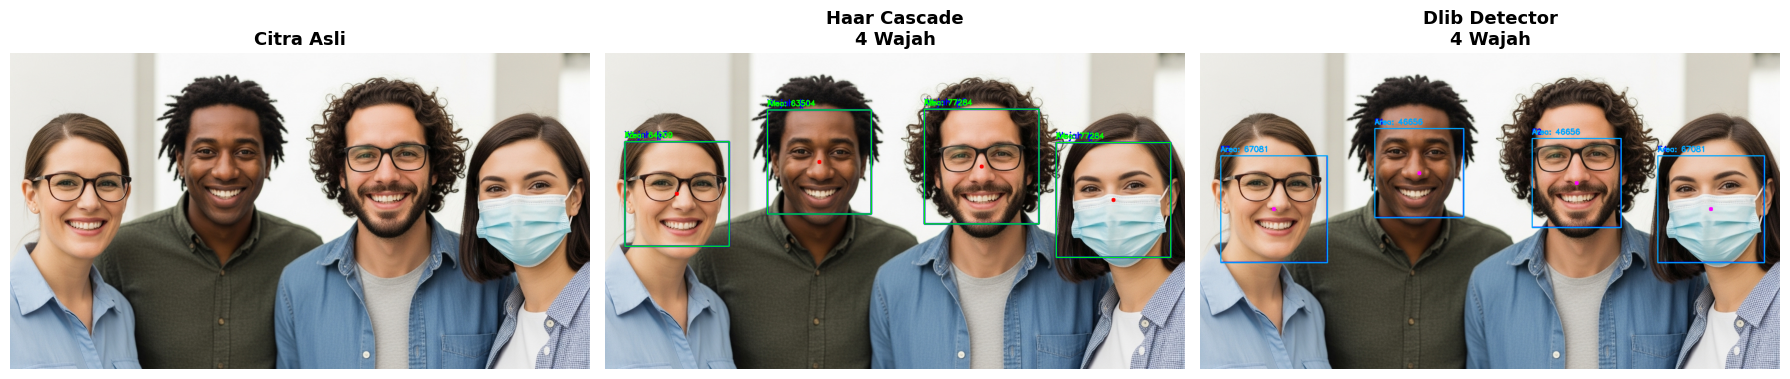


RINGKASAN HASIL DETEKSI WAJAH
Jumlah wajah (Haar Cascade) : 4
Jumlah wajah (Dlib)         : 4

Interpretasi Hasil:
- Kedua metode memberikan hasil deteksi yang sama.

Karakteristik Metode:
- Haar Cascade : proses cepat dan komputasi ringan.
- Dlib         : lebih robust terhadap variasi posisi wajah.


In [ ]:
# ========================================
# VISUALISASI HASIL DETEKSI
# ========================================

img_original_rgb = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
img_haar_rgb = cv2.cvtColor(img_haar, cv2.COLOR_BGR2RGB)
img_dlib_rgb = cv2.cvtColor(img_dlib, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Gambar Asli
axes[0].imshow(img_original_rgb)
axes[0].set_title("Citra Asli", fontsize=13, fontweight='bold')
axes[0].axis("off")

# Haar Cascade
axes[1].imshow(img_haar_rgb)
axes[1].set_title(
    f"Haar Cascade\n{len(faces_haar)} Wajah",
    fontsize=13,
    fontweight='bold'
)
axes[1].axis("off")

# Dlib
axes[2].imshow(img_dlib_rgb)
axes[2].set_title(
    f"Dlib Detector\n{len(faces_dlib)} Wajah",
    fontsize=13,
    fontweight='bold'
)
axes[2].axis("off")

plt.tight_layout()
plt.show()

# ========================================
# RINGKASAN HASIL
# ========================================

print("\n" + "="*60)
print("RINGKASAN HASIL DETEKSI WAJAH")
print("="*60)

haar_count = len(faces_haar)
dlib_count = len(faces_dlib)

print(f"Jumlah wajah (Haar Cascade) : {haar_count}")
print(f"Jumlah wajah (Dlib)         : {dlib_count}")

print("\nInterpretasi Hasil:")

if haar_count == dlib_count:

    print(
        "- Kedua metode memberikan hasil deteksi yang sama."
    )

elif haar_count > dlib_count:

    print(
        "- Haar Cascade mendeteksi lebih banyak wajah."
    )
    print(
        "- Kemungkinan terdapat objek yang dianggap wajah oleh Haar Cascade."
    )

else:

    print(
        "- Dlib mendeteksi lebih banyak wajah."
    )
    print(
        "- Dlib mampu mengenali beberapa wajah yang tidak terdeteksi oleh Haar Cascade."
    )

print("\nKarakteristik Metode:")
print("- Haar Cascade : proses cepat dan komputasi ringan.")
print("- Dlib         : lebih robust terhadap variasi posisi wajah.")
print("="*60)

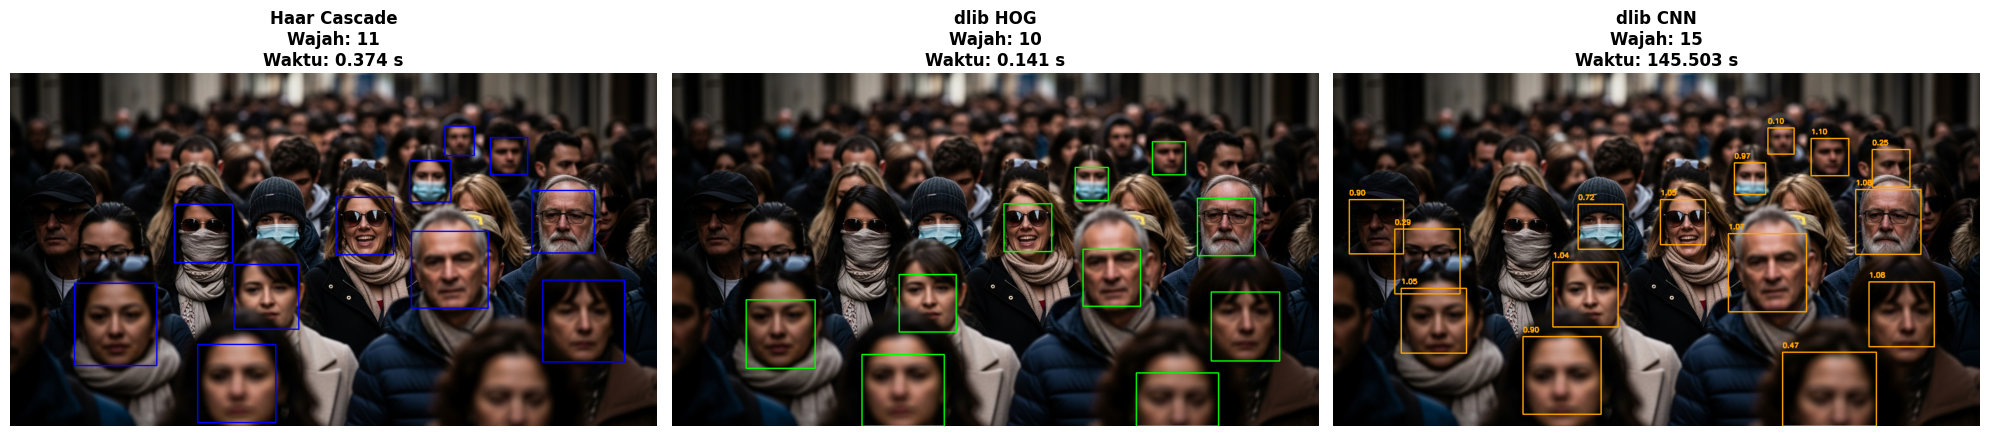


===== HASIL PERBANDINGAN =====
Haar Cascade : 11 wajah | 0.374 s
dlib HOG     : 10 wajah | 0.141 s
dlib CNN     : 15 wajah | 145.503 s


In [ ]:
import os
import cv2
import dlib
import bz2
import time
import requests
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# LOAD IMAGE
# ==========================
image_path = os.path.join(os.getcwd(), "data", "multiple2.png")

img = cv2.imread(image_path)

if img is None:
    raise FileNotFoundError(f"Gambar tidak ditemukan:\n{image_path}")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ==========================
# HAAR CASCADE
# ==========================
haar_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
face_cascade = cv2.CascadeClassifier(haar_path)

start = time.time()

faces_haar = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30)
)

haar_time = time.time() - start

img_haar = img.copy()

for (x, y, w, h) in faces_haar:
    cv2.rectangle(img_haar, (x, y), (x+w, y+h), (255, 0, 0), 2)

# ==========================
# DLIB HOG
# ==========================
detector = dlib.get_frontal_face_detector()

start = time.time()

faces_hog = detector(gray)

hog_time = time.time() - start

img_hog = img.copy()

for face in faces_hog:
    x1 = max(0, face.left())
    y1 = max(0, face.top())
    x2 = min(img.shape[1], face.right())
    y2 = min(img.shape[0], face.bottom())

    cv2.rectangle(img_hog, (x1, y1), (x2, y2), (0, 255, 0), 2)

# ==========================
# DLIB CNN
# ==========================
cnn_model = "mmod_human_face_detector.dat"

if not os.path.exists(cnn_model):

    print("Mengunduh model CNN dlib...")

    url = (
        "https://github.com/davisking/dlib-models/raw/master/"
        "mmod_human_face_detector.dat.bz2"
    )

    compressed_file = cnn_model + ".bz2"

    response = requests.get(url)

    with open(compressed_file, "wb") as f:
        f.write(response.content)

    print("Ekstraksi model...")

    with bz2.BZ2File(compressed_file) as fr, open(cnn_model, "wb") as fw:
        fw.write(fr.read())

    os.remove(compressed_file)

    print("Model berhasil disimpan.")

cnn_detector = dlib.cnn_face_detection_model_v1(cnn_model)

start = time.time()

faces_cnn = cnn_detector(img, 1)

cnn_time = time.time() - start

img_cnn = img.copy()

for face in faces_cnn:

    rect = face.rect

    x1 = max(0, rect.left())
    y1 = max(0, rect.top())
    x2 = min(img.shape[1], rect.right())
    y2 = min(img.shape[0], rect.bottom())

    confidence = face.confidence

    cv2.rectangle(img_cnn, (x1, y1), (x2, y2), (0, 165, 255), 2)

    cv2.putText(
        img_cnn,
        f"{confidence:.2f}",
        (x1, y1 - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 165, 255),
        2
    )

# ==========================
# CONVERT RGB
# ==========================
img_haar_rgb = cv2.cvtColor(img_haar, cv2.COLOR_BGR2RGB)
img_hog_rgb = cv2.cvtColor(img_hog, cv2.COLOR_BGR2RGB)
img_cnn_rgb = cv2.cvtColor(img_cnn, cv2.COLOR_BGR2RGB)

# ==========================
# VISUALIZATION
# ==========================
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

axes[0].imshow(img_haar_rgb)
axes[0].set_title(
    f"Haar Cascade\n"
    f"Wajah: {len(faces_haar)}\n"
    f"Waktu: {haar_time:.3f} s",
    fontsize=12,
    fontweight='bold'
)
axes[0].axis("off")

axes[1].imshow(img_hog_rgb)
axes[1].set_title(
    f"dlib HOG\n"
    f"Wajah: {len(faces_hog)}\n"
    f"Waktu: {hog_time:.3f} s",
    fontsize=12,
    fontweight='bold'
)
axes[1].axis("off")

axes[2].imshow(img_cnn_rgb)
axes[2].set_title(
    f"dlib CNN\n"
    f"Wajah: {len(faces_cnn)}\n"
    f"Waktu: {cnn_time:.3f} s",
    fontsize=12,
    fontweight='bold'
)
axes[2].axis("off")

plt.tight_layout()
plt.show()

# ==========================
# SUMMARY
# ==========================
print("\n===== HASIL PERBANDINGAN =====")
print(f"Haar Cascade : {len(faces_haar)} wajah | {haar_time:.3f} s")
print(f"dlib HOG     : {len(faces_hog)} wajah | {hog_time:.3f} s")
print(f"dlib CNN     : {len(faces_cnn)} wajah | {cnn_time:.3f} s")